In [1]:
# SPDX-License-Identifier: MIT

# Tutorial 5 — Inside a VECSEL: chip, cavity, filters and frequency noise

**Pre-G1, exploratory, not promoted.** These are teaching models, not a
simulation or linewidth prediction for an accepted laboratory design.
You need basic waves, optical power and Python arrays; no semiconductor
device simulation experience is assumed.

[Open in Colab](https://colab.research.google.com/github/uwarring82/mg-plus-uv-chain/blob/main/docs/tutorials/05-vecsel-principles-noise.ipynb).
Save a copy to Drive, use a CPU runtime and run all cells. Setup fetches
reviewed shared code when no checkout exists. All new example parameters
live in this notebook, so an isolated copy contains its teaching inputs.
Edit the experiment cell to preserve changes with your saved notebook.
[Student guide](https://uwarring82.github.io/mg-plus-uv-chain/tutorials/).

In [2]:
from __future__ import annotations

import os
import subprocess
import sys
import tempfile
from pathlib import Path

# A local checkout uses its own code. Colab starts without a checkout, so
# fetch a fixed reviewed revision into a temporary runtime directory.
REFERENCE_REVISION = "3466c3262aa72af93f10a3699c48782d401548f8"
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "src" / "enhancement_cavity.py").is_file():
    if REPO_ROOT == REPO_ROOT.parent:
        break
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "src" / "enhancement_cavity.py").is_file():
    REPO_ROOT = Path(tempfile.mkdtemp(prefix="mg-uv-tutorial-"))
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "https://github.com/uwarring82/mg-plus-uv-chain.git",
            str(REPO_ROOT),
        ],
        check=True,
    )
    subprocess.run(
        ["git", "-C", str(REPO_ROOT), "checkout", "--quiet", REFERENCE_REVISION],
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "-e", str(REPO_ROOT)],
        check=True,
    )
    os.chdir(REPO_ROOT)
    print("Runtime code and inputs:", REFERENCE_REVISION)
sys.path.insert(0, str(REPO_ROOT))


import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
from matplotlib.patches import Arc, Rectangle  # noqa: E402
from scipy.integrate import trapezoid  # noqa: E402

from src.parameters import SPEED_OF_LIGHT_m_per_s as c  # noqa: E402

## Your experiment

The default wavelength illustrates the magnesium seed band. Every other
numerical value below is a chosen teaching input, not a measured device
parameter. Geometry is inspired by the linear-cavity topology in
[Burd et al. (2023), Sec. 2 and Fig. 2](https://tf.nist.gov/general/pdf/3090.pdf),
which describes different wavelengths. No measured linewidth is imported.

Try `{"noise": {"pump_rin_asd_per_sqrtHz": 2e-7}}` to reduce pump
amplitude spectral density tenfold. Use `{}` to restore the defaults.
Run this cell and the cells below it again after an edit.

In [3]:
parameter_overrides = {}

In [4]:
params = {
    "optics": {
        "wavelength_m": 1118e-9,
        "optical_length_m": 0.125,
        "brf_thickness_m": 0.003,
        "brf_delta_n": 0.009,
        "etalon_thickness_m": 0.001,
        "etalon_group_index": 1.82,
        "etalon_reflectivity": 0.60,
        "etalon_detuning_Hz": 0.0,
    },
    "noise": {
        "length_asd_m_per_sqrtHz": 3e-14,
        "temperature_asd_K_per_sqrtHz": 2e-6,
        "thermal_tuning_Hz_per_K": 5e7,
        "pump_power_W": 10.0,
        "pump_rin_asd_per_sqrtHz": 2e-6,
        "pump_thermal_Hz_per_W": 2e6,
        "pump_fast_Hz_per_W": 2e5,
        "driver_asd_V_per_sqrtHz": 1e-6,
        "pzt_tuning_Hz_per_V": 1e8,
        "white_frequency_psd_Hz2_per_Hz": 1e3,
        "servo_bandwidth_Hz": 1e4,
    },
}
for section, changes in parameter_overrides.items():
    if section not in params or not isinstance(changes, dict):
        raise ValueError("Use a dictionary under 'optics' or 'noise'.")
    if changes.keys() - params[section].keys():
        raise KeyError(f"Unknown parameters in {section}")
    params[section].update(changes)
o, n = params["optics"], params["noise"]
assert all(v > 0 for k, v in o.items() if k != "etalon_detuning_Hz")
assert 0 < o["etalon_reflectivity"] < 1
assert all(v >= 0 for v in n.values()) and n["servo_bandwidth_Hz"] > 0
nu0 = c / o["wavelength_m"]
fsr_cavity = c / (2 * o["optical_length_m"])
fsr_etalon = c / (2 * o["etalon_group_index"] * o["etalon_thickness_m"])
fsr_brf = c / (o["brf_delta_n"] * o["brf_thickness_m"])
print("Illustrative FSRs, not measured hardware values:")
print(f"  cavity {fsr_cavity / 1e9:.6f} GHz; etalon {fsr_etalon / 1e9:.6f} GHz")
print(f"  ideal one-plate BRF {fsr_brf / 1e12:.6f} THz")

Illustrative FSRs, not measured hardware values:
  cavity 1.199170 GHz; etalon 82.360565 GHz
  ideal one-plate BRF 11.103424 THz


## 1. The chip supplies gain; the external cavity supplies feedback

An optical pump creates carriers in the semiconductor barriers. Carriers
relax into quantum wells, where stimulated emission amplifies the resonant
field. A distributed Bragg reflector (DBR) supplies feedback. Placing wells
near standing-wave antinodes improves overlap: this is resonant periodic
gain. A thermal contact and heat spreader carry pump-deposited heat away.
The layer order and heat-spreader placement vary between chip designs.
[Burd et al. (2023), Sec. 2](https://tf.nist.gov/general/pdf/3090.pdf).

The schematic is an original conceptual drawing, not a fabrication recipe.
A long external cavity can give a photon lifetime longer than the carrier
lifetime (class-A dynamics). This condition can suppress relaxation
oscillations; it does not remove technical noise or establish a linewidth.

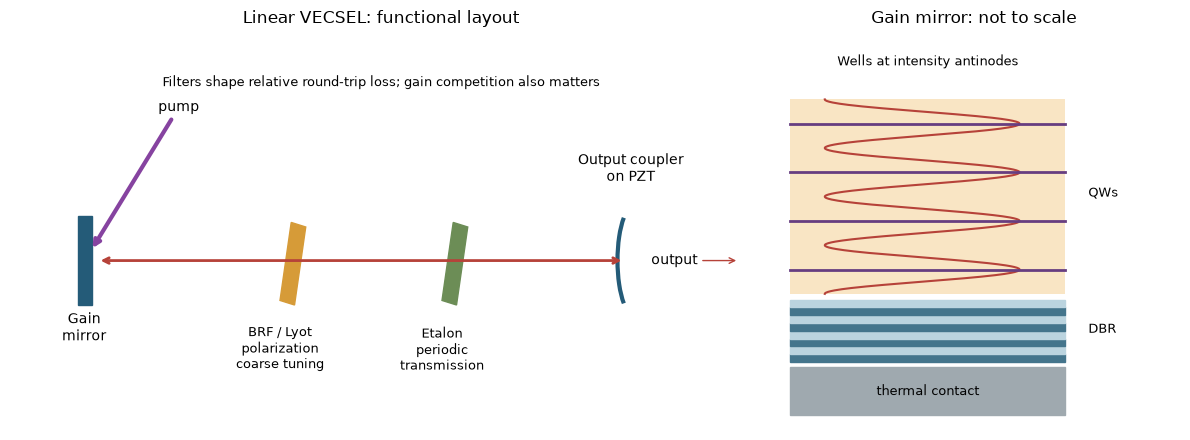

In [5]:
fig, (ax, chip) = plt.subplots(1, 2, figsize=(12, 4.5), width_ratios=[1.8, 1])
ax.set(xlim=(0, 11), ylim=(-1.7, 2.3), title="Linear VECSEL: functional layout")
ax.axis("off")
ax.add_patch(Rectangle((1, -0.45), 0.22, 0.9, color="#245b78"))
ax.annotate(
    "", (9.1, 0), (1.3, 0), arrowprops=dict(arrowstyle="<->", lw=2, color="#b64239")
)
for x, label, color in [
    (4, "BRF / Lyot\npolarization\ncoarse tuning", "#d69b38"),
    (6.4, "Etalon\nperiodic\ntransmission", "#6c8d56"),
]:
    ax.add_patch(Rectangle((x, -0.4), 0.22, 0.8, angle=-12, color=color))
    ax.text(x, -0.65, label, ha="center", va="top", fontsize=9)
ax.add_patch(Arc((9.25, 0), 0.5, 1.1, theta1=110, theta2=250, lw=3, color="#245b78"))
ax.text(9.2, 0.8, "Output coupler\non PZT", ha="center", fontsize=10)
ax.annotate(
    "output",
    (10.8, 0),
    (9.5, 0),
    arrowprops=dict(arrowstyle="->", color="#b64239"),
    va="center",
)
ax.annotate(
    "pump",
    (1.2, 0.1),
    (2.5, 1.5),
    arrowprops=dict(arrowstyle="->", color="#8643a0", lw=3),
    ha="center",
)
ax.text(1.1, -0.8, "Gain\nmirror", ha="center")
ax.text(
    5.5,
    1.75,
    "Filters shape relative round-trip loss; gain competition also matters",
    ha="center",
    fontsize=9,
)
chip.set(xlim=(0, 3.6), ylim=(0, 4.1), title="Gain mirror: not to scale")
chip.axis("off")
chip.add_patch(Rectangle((0.2, 0.15), 2.4, 0.5, color="#9fa9af"))
chip.text(1.4, 0.4, "thermal contact", ha="center", va="center", fontsize=9)
for i in range(8):
    chip.add_patch(
        Rectangle((0.2, 0.7 + i * 0.08), 2.4, 0.08, color=["#44758c", "#bbd4df"][i % 2])
    )
chip.text(2.8, 1.0, "DBR", fontsize=9)
chip.add_patch(Rectangle((0.2, 1.4), 2.4, 2.0, facecolor="#f9e5c4"))
z = np.linspace(1.4, 3.4, 500)
field_intensity = np.sin(2 * np.pi * (z - 1.4)) ** 2
chip.plot(0.5 + 1.7 * field_intensity, z, color="#b64239", lw=1.5)
for level in [1.65, 2.15, 2.65, 3.15]:
    chip.plot([0.2, 2.6], [level, level], color="#673d80", lw=2)
chip.text(2.8, 2.4, "QWs", fontsize=9)
chip.text(1.4, 3.75, "Wells at intensity antinodes", ha="center", fontsize=9)
fig.tight_layout()

## 2. Cavity modes, a birefringent plate and an etalon

For a nondispersive linear cavity of one-way optical length L, the modes
obey nu_q=q*c/(2L), with FSR=c/(2L). Mirror phase and group delay can modify
the effective length; we omit them here.

**BRF / Lyot:** resolve a linearly polarized field along two crystal axes,
accumulate a relative retardance, then project back onto the selected
polarization. An ideal plate at 45 degrees between parallel polarizers has
T=cos²(delta/2), delta=2*pi*nu*Delta_n*d/c. In a real Brewster-cut
intracavity plate the geometry and round trip require a Jones-matrix model.
Here we shift the ideal passband to zero detuning and hold Delta_n fixed.

**Etalon:** sum multiply reflected fields in a plane-parallel slab. For
identical lossless faces of power reflectivity R, its Airy transmission is
T=1/[1+F*sin²(pi*detuning/FSR)], F=4R/(1-R)². The normal-incidence
FSR uses the group index: c/(2*n_g*d). Tilt and temperature move its peaks.

Below, a Gaussian gain envelope times these *single-pass* ideal filter
transmissions is only a relative spectral weight, not a laser threshold
or modal-power calculation. Neither a broad passband nor a cavity FSR is
the laser linewidth. Several cavity modes may fit inside an etalon peak.
The BRF + etalon + PZT hierarchy is used in
[Burd et al. (2023), Sec. 2](https://tf.nist.gov/general/pdf/3090.pdf).

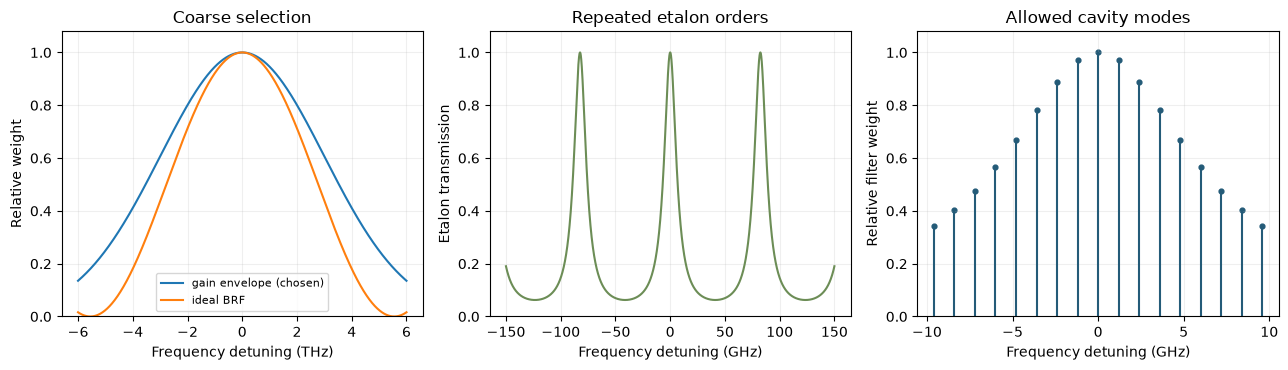

In [6]:
def etalon_transmission(detuning_Hz: float | np.ndarray) -> float | np.ndarray:
    """Return dimensionless ideal intensity transmission at detuning in Hz."""
    reflectivity = o["etalon_reflectivity"]
    coefficient = 4 * reflectivity / (1 - reflectivity) ** 2
    phase = np.pi * (np.asarray(detuning_Hz) - o["etalon_detuning_Hz"]) / fsr_etalon
    return 1 / (1 + coefficient * np.sin(phase) ** 2)


def brf_transmission(detuning_Hz: float | np.ndarray) -> float | np.ndarray:
    """Return dimensionless ideal one-plate transmission at detuning in Hz."""
    return np.cos(np.pi * np.asarray(detuning_Hz) / fsr_brf) ** 2


fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
broad = np.linspace(-6e12, 6e12, 2000)
axes[0].plot(
    broad / 1e12, np.exp(-0.5 * (broad / 3e12) ** 2), label="gain envelope (chosen)"
)
axes[0].plot(broad / 1e12, brf_transmission(broad), label="ideal BRF")
axes[0].set(
    xlabel="Frequency detuning (THz)",
    ylabel="Relative weight",
    title="Coarse selection",
)
medium = np.linspace(-150e9, 150e9, 12000)
axes[1].plot(medium / 1e9, etalon_transmission(medium), color="#6c8d56")
axes[1].set(
    xlabel="Frequency detuning (GHz)",
    ylabel="Etalon transmission",
    title="Repeated etalon orders",
)
modes = np.arange(-8, 9) * fsr_cavity
weights = etalon_transmission(modes) * brf_transmission(modes)
axes[2].vlines(modes / 1e9, 0, weights, color="#245b78")
axes[2].scatter(modes / 1e9, weights, s=12, color="#245b78")
axes[2].set(
    xlabel="Frequency detuning (GHz)",
    ylabel="Relative filter weight",
    title="Allowed cavity modes",
)
axes[0].legend(fontsize=8)
for ax in axes:
    ax.grid(alpha=0.2)
    ax.set_ylim(0, 1.08)
fig.tight_layout()

## 3. From a disturbed component to frequency noise

Differentiating the resonance condition at fixed mode number gives
delta_nu/nu = -delta_Lopt/Lopt. This is a useful direct path-length
sensitivity, not a complete model of gain pulling, filter dispersion,
carrier-index dynamics or mode hops. A gain-peak temperature coefficient
is therefore not automatically the laser-frequency temperature coefficient.

| Disturbance | Coupling | Measurement / variation |
|---|---|---|
| Vibration | mirror or air path | accelerometer coherence; mount change |
| Temperature | expansion, index, gain pulling | temperature modulation |
| Pump power | heating and carrier index | RIN and complex Hz/W response |
| PZT voltage | displacement and resonances | voltage PSD; Hz/V calibration |
| Reference / sensor | laser-frequency feedback | reference PSD; loop response |

Pump stabilization reduced measured frequency noise in a different VECSEL
in [Lee, Moriya & Hastie (2023), Fig. 4](https://strathprints.strath.ac.uk/87108/7/Lee-etal-OE-2023-Monolithic-VECSEL-for-stable-kHz-linewidth.pdf).
That supports the mechanism, not the amplitudes chosen in this notebook.

1 pm optical-length change -> -2145.205 Hz frequency change


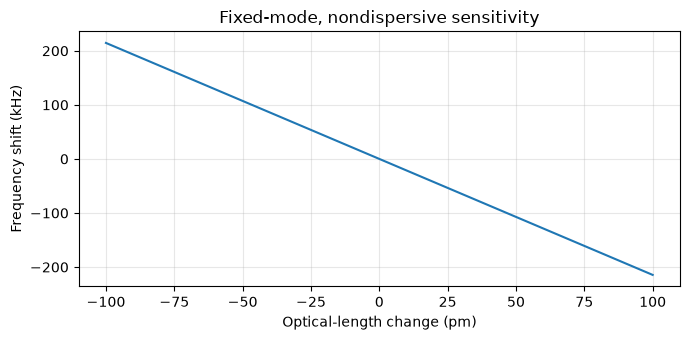

In [7]:
length_sensitivity = -nu0 / o["optical_length_m"]
print(
    "1 pm optical-length change -> "
    f"{length_sensitivity * 1e-12:.3f} Hz frequency change"
)
shift = np.linspace(-100e-12, 100e-12, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(shift * 1e12, length_sensitivity * shift / 1e3)
ax.set(
    xlabel="Optical-length change (pm)",
    ylabel="Frequency shift (kHz)",
    title="Fixed-mode, nondispersive sensitivity",
)
ax.grid(alpha=0.3)
fig.tight_layout()

## 4. A synthetic noise budget and two different locks

S_nu(f) is a **one-sided** frequency-noise PSD in Hz²/Hz; f is an ordinary
Fourier frequency in Hz, not an angular frequency. ASD is its square root.
For an input x with transfer H_nu,x(f), S_nu=|H|²*S_x.
Independent inputs add as PSDs; correlated inputs require cross spectra.
Here the thermal and fast pump paths share the same pump fluctuation, so
their complex transfer amplitudes are added **before** taking |H|².
The chosen fast path is an effective carrier/index coupling, not a Henry
alpha calculation. The white floor is illustrative; it is not a measured
Schawlow–Townes limit. Sharp deterministic tones and mode hops are omitted.

An ideal integral **laser-frequency lock** has G=fb/(i*f). Its output PSD
is |1/(1+G)|²*S_free + |G/(1+G)|²*S_reference, assuming independent inputs.
The reference term below includes sensor noise expressed as equivalent Hz.
Delay, actuator limits and servo resonances are omitted.

A **doubling-cavity tracking lock** instead moves that cavity to follow
the incident laser. It suppresses *relative detuning*, not the seed laser's
absolute frequency noise. Conversion to intensity noise needs the optical
discriminator and operating point; at the exact peak the static first
derivative of transmitted power with detuning is zero. We do not infer UV
RIN from a lock bandwidth alone.

free seed: RMS frequency deviation over 1 Hz–1 MHz = 32611.007 Hz (not linewidth)
frequency-locked seed: RMS frequency deviation over 1 Hz–1 MHz = 31668.258 Hz (not linewidth)


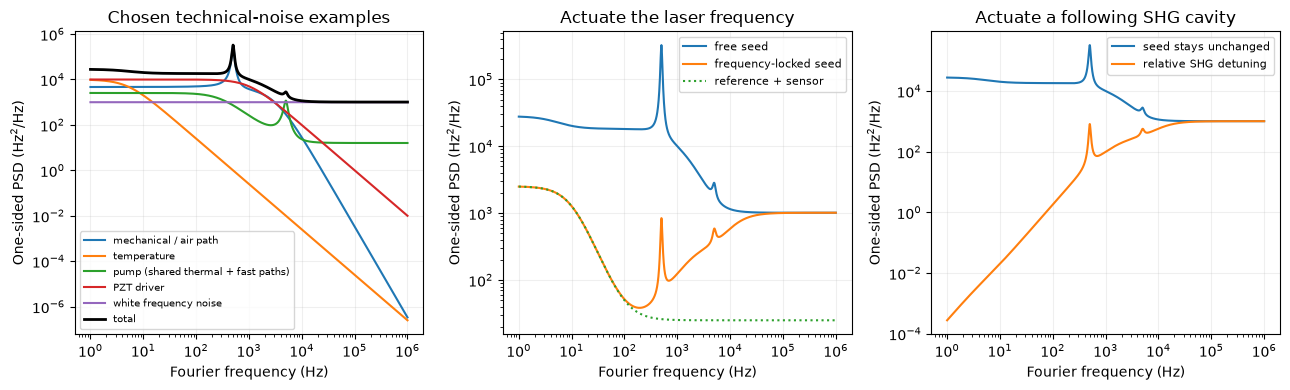

In [8]:
f = np.geomspace(1.0, 1e6, 6000)
length_psd = (n["length_asd_m_per_sqrtHz"] / (1 + (f / 3000) ** 2)) ** 2
length_psd *= 1 + 80 / (1 + ((f - 500) / 20) ** 2)
temperature_psd = n["temperature_asd_K_per_sqrtHz"] ** 2 / (1 + (f / 5) ** 2)
pump_rin_psd = n["pump_rin_asd_per_sqrtHz"] ** 2 * (
    1 + 50 / (1 + ((f - 5000) / 400) ** 2)
)
pump_transfer = (
    n["pump_thermal_Hz_per_W"] / (1 + 1j * f / 300) + n["pump_fast_Hz_per_W"]
)
parts = {
    "mechanical / air path": length_sensitivity**2 * length_psd,
    "temperature": n["thermal_tuning_Hz_per_K"] ** 2 * temperature_psd,
    "pump (shared thermal + fast paths)": np.abs(pump_transfer) ** 2
    * n["pump_power_W"] ** 2
    * pump_rin_psd,
    "PZT driver": (n["pzt_tuning_Hz_per_V"] * n["driver_asd_V_per_sqrtHz"]) ** 2
    / (1 + (f / 1000) ** 2),
    "white frequency noise": np.full_like(f, n["white_frequency_psd_Hz2_per_Hz"]),
}
free_psd = sum(parts.values())
loop = n["servo_bandwidth_Hz"] / (1j * f)
suppression = np.abs(1 / (1 + loop)) ** 2
tracking = np.abs(loop / (1 + loop)) ** 2
reference_psd = 25 + 2500 / (1 + (f / 10) ** 2)
locked_psd = suppression * free_psd + tracking * reference_psd
shg_detuning_psd = suppression * free_psd
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for label, psd in parts.items():
    axes[0].loglog(f, psd, label=label)
axes[0].loglog(f, free_psd, "k", lw=2, label="total")
axes[0].set_title("Chosen technical-noise examples")
axes[0].legend(fontsize=7.5, loc="lower left")
axes[1].loglog(f, free_psd, label="free seed")
axes[1].loglog(f, locked_psd, label="frequency-locked seed")
axes[1].loglog(f, reference_psd, ":", label="reference + sensor")
axes[1].set_title("Actuate the laser frequency")
axes[1].legend(fontsize=8)
axes[2].loglog(f, free_psd, label="seed stays unchanged")
axes[2].loglog(f, shg_detuning_psd, label="relative SHG detuning")
axes[2].set_title("Actuate a following SHG cavity")
axes[2].legend(fontsize=8)
for ax in axes:
    ax.set(xlabel="Fourier frequency (Hz)", ylabel=r"One-sided PSD (Hz$^2$/Hz)")
    ax.grid(alpha=0.2)
fig.tight_layout()
for label, psd in [("free seed", free_psd), ("frequency-locked seed", locked_psd)]:
    print(
        f"{label}: RMS frequency deviation over 1 Hz–1 MHz = "
        f"{np.sqrt(trapezoid(psd, f)):.3f} Hz (not linewidth)"
    )

## 5. Why an integrated PSD is not automatically a linewidth

For Gaussian stationary frequency noise, phase obeys d_phi/dt=2*pi*delta_nu.
The phase-increment variance is 4*integral[S_nu(f)*sin²(pi*f*tau)/f² df].
Since a Gaussian phase increment has <exp(i*delta_phi)>=exp(-variance/2),
the normalized field coherence is

$$g^{(1)}(\tau)=\exp\left[-2\int_0^\infty S_\nu(f)
            \frac{\sin^2(\pi f\tau)}{f^2}\,df\right].$$

The optical line shape is the Fourier transform of this coherence. For
ideal white S_nu=h0 over all positive frequencies, the integral gives
g1=exp(-pi²*h0*|tau|), hence a Lorentzian **FWHM=pi*h0**. In contrast,
sqrt(integral S_nu df) is a bandwidth-dependent RMS frequency deviation.
Colored noise, drift and a finite observation interval require the spectrum
and measurement procedure to be stated; no universal linewidth multiplier
converts that RMS value into FWHM.

This is the frequency-noise/coherence approach discussed by
[Di Domenico, Schilt & Thomann (2010)](https://doi.org/10.1364/AO.49.004801)
and applied to a VECSEL in
[Lee et al. (2023), Sec. 4](https://strathprints.strath.ac.uk/87108/7/Lee-etal-OE-2023-Monolithic-VECSEL-for-stable-kHz-linewidth.pdf).
Our numerical curves assume the PSD is zero outside **1 Hz–1 MHz**.
They are band-limited coherence examples, not claimed measured linewidths.

Ideal white-only Lorentzian FWHM = 3141.592654 Hz; not total technical linewidth


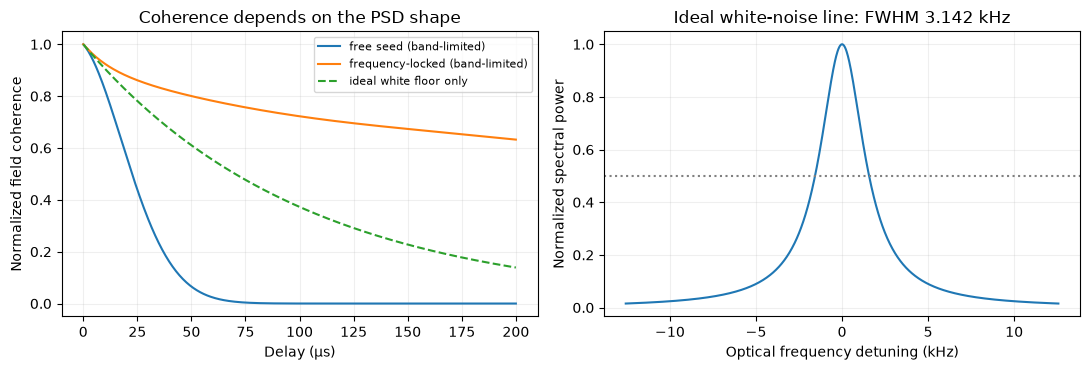

In [9]:
def coherence_from_psd(
    frequency_Hz: np.ndarray, psd_Hz2_per_Hz: np.ndarray, delay_s: np.ndarray
) -> np.ndarray:
    """Return dimensionless Gaussian field coherence for one-sided, band-limited PSD."""
    kernel = np.sin(np.pi * np.outer(delay_s, frequency_Hz)) ** 2 / frequency_Hz**2
    return np.exp(-2 * trapezoid(kernel * psd_Hz2_per_Hz, frequency_Hz, axis=1))


tau = np.linspace(0, 200e-6, 500)
h0 = n["white_frequency_psd_Hz2_per_Hz"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(
    tau * 1e6, coherence_from_psd(f, free_psd, tau), label="free seed (band-limited)"
)
axes[0].plot(
    tau * 1e6,
    coherence_from_psd(f, locked_psd, tau),
    label="frequency-locked (band-limited)",
)
axes[0].plot(
    tau * 1e6, np.exp(-np.pi**2 * h0 * tau), "--", label="ideal white floor only"
)
axes[0].set(
    xlabel="Delay (µs)",
    ylabel="Normalized field coherence",
    title="Coherence depends on the PSD shape",
)
axes[0].legend(fontsize=8)
white_fwhm = np.pi * h0
if white_fwhm > 0:
    detuning = np.linspace(-4 * white_fwhm, 4 * white_fwhm, 1000)
    axes[1].plot(detuning / 1e3, 1 / (1 + (2 * detuning / white_fwhm) ** 2))
    axes[1].axhline(0.5, color="gray", ls=":")
    axes[1].set(
        xlabel="Optical frequency detuning (kHz)",
        ylabel="Normalized spectral power",
        title=f"Ideal white-noise line: FWHM {white_fwhm/1e3:.3f} kHz",
    )
else:
    axes[1].text(0.5, 0.5, "Zero white floor: delta-line limit", ha="center")
for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
print(
    f"Ideal white-only Lorentzian FWHM = {white_fwhm:.6f} Hz; "
    "not total technical linewidth"
)

## Checks, exercises and a measurement plan

The checks below test periodic transmission, the exact resonance shift,
the ideal feedback limit, and an independent white-noise coherence limit.
They do not validate a particular VECSEL's noise amplitudes.

1. Double the optical length. Predict both the FSR and Hz-per-pm sensitivity.
2. Move the etalon peak by half a cavity FSR. Which modes have similar
   filter weight? Explain why this alone cannot predict mode competition.
3. Reduce pump ASD tenfold. Its frequency-noise PSD should fall 100-fold;
   identify where other noise terms now dominate.
4. Increase the ideal servo bandwidth. Identify the reference-noise floor
   and explain why a real loop also needs phase-margin and actuator checks.
5. Change the integration band and explain why RMS deviation changes even
   for white noise while its ideal Lorentzian FWHM is unchanged.

To contribute real data, include a calibrated frequency discriminator or
beat note, the reference-laser noise, PSD normalization, observation time,
frequency band, and any detrending/windowing. Measure transfer functions
rather than replacing them by a gain-peak temperature slope. Record RIN
and cross spectra where inputs may be correlated. A scanning-cavity width,
mode spacing and an optical beat-note linewidth are different observables.

In [10]:
assert np.isclose(etalon_transmission(o["etalon_detuning_Hz"]), 1.0)
assert np.isclose(etalon_transmission(o["etalon_detuning_Hz"] + fsr_etalon), 1.0)
assert np.isclose(brf_transmission(fsr_brf), 1.0)
delta_length = 1e-12
exact_shift = -nu0 * delta_length / (o["optical_length_m"] + delta_length)
assert np.isclose(length_sensitivity * delta_length, exact_shift, rtol=1e-9)
assert np.allclose(suppression + tracking, 1.0)
assert np.isclose(coherence_from_psd(f, free_psd, np.array([0.0]))[0], 1.0)
check_f = np.geomspace(1e-4, 1e9, 100000)
check_tau = np.array([1e-6, 1e-5])
white_check = coherence_from_psd(check_f, np.full_like(check_f, 1000.0), check_tau)
assert np.allclose(white_check, np.exp(-np.pi**2 * 1000.0 * check_tau), rtol=0.002)
print("All teaching-model checks passed.")

All teaching-model checks passed.


## Further reading

- [Burd et al. 2016: magnesium VECSEL systems](https://arxiv.org/abs/1606.03484).
- [Burd et al. 2023: cavity, chip and filtering](https://tf.nist.gov/general/pdf/3090.pdf).
- [Lee, Moriya & Hastie 2023: technical noise and linewidth measurements](https://strathprints.strath.ac.uk/87108/7/Lee-etal-OE-2023-Monolithic-VECSEL-for-stable-kHz-linewidth.pdf).
- [Di Domenico et al. 2010: frequency noise and line shape](https://doi.org/10.1364/AO.49.004801).
- [In-house VECSEL narrative and evidence labels](https://uwarring82.github.io/mg-plus-uv-chain/tutorials/vecsel-systems.html).
- [Student contribution guide](https://uwarring82.github.io/mg-plus-uv-chain/tutorials/).